# Assignment 2

In [1]:
# All important packages 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2, norm
import math as m
from scipy.optimize import brentq, minimize_scalar, root_scalar

## Question 1 - CStats

We are given $n_{on}$, which is counts in the detector. $ n_{on}=n_s + n_{bkg}$ 

Now, we are given that we know the background of the source due to modeling, hence our probability only depends only on the counts from the source, that is it has a poissonian distribution.
$$
    P(n|\mu) = \frac{e^{-\mu} \mu^n}{n!} = \frac{e^{-(s+b)}(s+b)^{n}}{n!}
$$
where, s is signal mean, b is background mean and n is the on counts of the detector.
<br>
From this our Likelihood becomes,
$$
    \mathcal{L}(s)= \frac{e^{-(s+b)}(s+b)^{n}}{n!} \\
    \implies \ln(\mathcal{L}(s))= -(s+b)+n \ln(s+b) - \ln n!
$$
Now, we will obtain the estimators using MLE,
$$
    \frac{d\ln(\mathcal{L}(s))}{ds} = -1 + \frac{n}{s+b} = 0 \\
    \implies \hat{s}=n-b
$$

Now, from this we can obtain the Profile Likelihood Test Statistics,
$$
    TS=-2\ln \frac{\mathcal{L}(s)}{\mathcal{L}(\hat{s})} = -2\ln \lambda(s) \text{ where, } \lambda = \frac{\mathcal{L}(s)}{\mathcal{L}(\hat{s})}
$$


Now, using Wilk's Theorem, we have 
$$
    \ln(s) = \ln(\hat{x}) - \frac{1}{2} \frac{(s-\hat{s})^2}{\sigma^2} 
$$

Now, since $\hat{s}$ is an estimator, it means that for different observatiosn we will have different values of $\hat{s}$, this means we have a distribution for $\hat{s}$. Using the Central Limit therem, for a large number of observations, we have 
$$
    (\frac{\hat{s} - s}{\sigma})^2 \approx \Chi^2
$$

#### Defining Cash Statistics


We define, $C(s)=-2\ln \mathcal{L}(s)$
$$
    TS = -2\ln(\frac{\mathcal{L}(\hat{s})}{\mathcal{L}(s)}) \\
    = 2 [\ln \mathcal{L}(s) - \ln \mathcal{L}(\hat{s}) ] \\
    \text{Using, Wilk's Theorem} \quad \quad \\
    = \Delta C(s) \approx \Chi^2
$$
From this we can obtain the significance as , $\sigma = \sqrt{\Delta C(s)}$.

#### Finding the Confidence Interval

In [2]:
def confidence_interval(n_on, b, sigma, two_sided=True):
    def C(s):
        return 2 * ((s + b) - n_on * np.log(s + b))

    s_hat = max(0, n_on - b)
    C_min = C(s_hat)

    # Correct threshold from chi2 distribution
    # For two-sided: confidence level = P(|Z| < sigma) = erf(sigma/sqrt(2))
    # For one-sided (upper limit): use one-sided probability
    if two_sided:
        cl = norm.cdf(sigma) - norm.cdf(-sigma)  # e.g. 0.6827 for 1sigma
    else:
        cl = norm.cdf(sigma) - norm.cdf(-sigma)  # same chi2 cutoff; directionality handled by only returning right root

    deltaC_target = chi2.ppf(cl, df=1)

    def f(s):
        return C(s) - C_min - deltaC_target

    # Left root (only meaningful for two-sided intervals)
    s_left = None
    if two_sided and s_hat > 0:
        if f(1e-10) * f(s_hat) < 0:
            s_left = root_scalar(f, bracket=[1e-10, s_hat], method='brentq').root
        else:
            s_left = 0.0

    # Right root
    s_max = max(s_hat + 1, 1.0)
    while f(s_hat) * f(s_max) > 0:
        s_max *= 2
        if s_max > 1e6:
            raise RuntimeError("Right root not found")
    s_right = root_scalar(f, bracket=[s_hat, s_max], method='brentq').root

    return s_left, s_right

#### Finding Upper Limit

In [3]:
def upper_limit(n_on, b, sigma_ul):
    """One-sided upper limit at sigma_ul significance."""
    def C(s):
        return 2 * ((s + b) - n_on * np.log(s + b))

    s_hat = max(0, n_on - b)
    C_min = C(s_hat)

    # One-sided: CL = norm.cdf(sigma_ul), threshold is chi2.ppf of that
    cl_one_sided = 2 * norm.cdf(sigma_ul) - 1  # = P(-sigma < Z < sigma)
    deltaC_target = chi2.ppf(cl_one_sided, df=1)

    def f(s):
        return C(s) - C_min - deltaC_target

    s_max = max(s_hat + 1, 1.0)
    while f(s_hat) * f(s_max) > 0:
        s_max *= 2
        if s_max > 1e6:
            raise RuntimeError("Upper limit root not found")

    return root_scalar(f, bracket=[s_hat, s_max], method='brentq').root

#### Plotting the Likelihood Profile

In [4]:
def plot_profile(n_on, b):
    def log_L(s):
        # log-likelihood: -0.5 * C(s), but we want the profile likelihood ratio
        return n_on * np.log(s + b) - (s + b)

    s_hat = max(0, n_on - b)
    log_L_max = log_L(s_hat)

    s_vals = np.linspace(0.01, 20, 5000)

    # Profile likelihood ratio: L(s)/L(s_hat) = exp(log_L(s) - log_L_max)
    profile_lr = np.exp(log_L(s_vals) - log_L_max)

    # Also compute deltaC for reference lines
    deltaC = -2 * (log_L(s_vals) - log_L_max)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: profile likelihood ratio (this is what "plot the profile likelihood" means)
    axes[0].plot(s_vals, profile_lr)
    axes[0].axvline(s_hat, linestyle=':', label='MLE')
    # Mark where profile LR = exp(-0.5) for 1sigma, exp(-2) for 2sigma
    axes[0].axhline(np.exp(-0.5), linestyle='--', color='green', label='1σ')
    axes[0].axhline(np.exp(-2.0), linestyle='--', color='red',   label='2σ')
    axes[0].set_xlabel('s')
    axes[0].set_ylabel('L(s) / L(ŝ)')
    axes[0].set_title(f'Profile Likelihood Ratio (n_on={n_on}, b={b})')
    axes[0].legend()
    axes[0].grid()

    # Right: -2 delta ln L (same info, chi2 scale — easier to read off intervals)
    axes[1].plot(s_vals, deltaC)
    axes[1].axvline(s_hat, linestyle=':', label='MLE')
    axes[1].axhline(chi2.ppf(norm.cdf(1)-norm.cdf(-1), 1), linestyle='--', color='green', label='1σ')
    axes[1].axhline(chi2.ppf(norm.cdf(2)-norm.cdf(-2), 1), linestyle='--', color='red',   label='2σ')
    axes[1].set_xlabel('s')
    axes[1].set_ylabel('−2Δln L')
    axes[1].set_title(f'−2Δln L Profile (n_on={n_on}, b={b})')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

**CASE 1 - $N_{on} = 10$ and $N_{bkg}=3$**

n_on=10, b=3 | excess=7.0
  1σ CI: 4.162 – 10.504
  2σ CI: 1.932 – 14.722


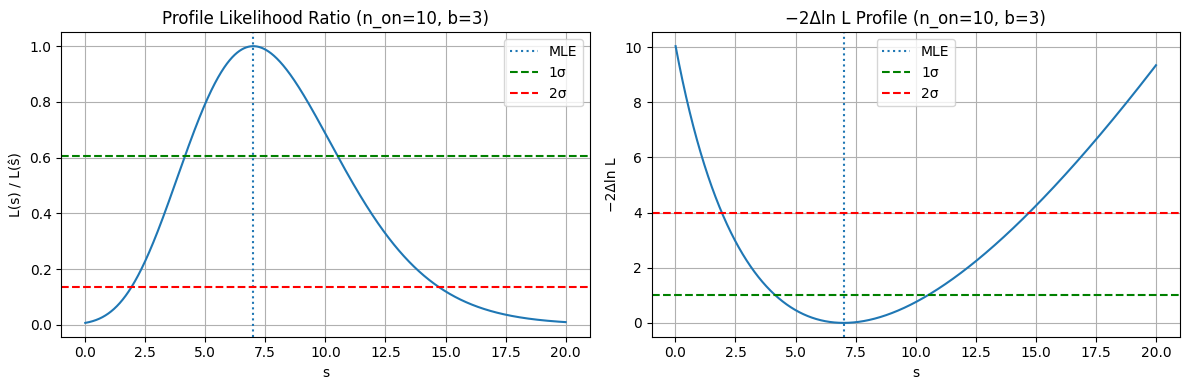

In [5]:
n_on, b = 10, 3
s_hat = max(0, n_on - b)

#Prinitng Excess
print(f"n_on={n_on}, b={b} | excess={s_hat:.1f}")

#Printing the confidence levels
print(f"  1σ CI: {confidence_interval(n_on, b, 1)[0]:.3f} – {confidence_interval(n_on, b, 1)[1]:.3f}")
print(f"  2σ CI: {confidence_interval(n_on, b, 2)[0]:.3f} – {confidence_interval(n_on, b, 2)[1]:.3f}")

#Plotting the Likelihood Profile and the MLE
plot_profile(n_on, b)

For the first case, given 
<br>
$ n_{on} = 10, n_{bkg} = 3 \implies \text{Excess}, \hat{s} = 10-3 = 7$


Now, the significance is $ \sigma = \sqrt{TS} = \sqrt{\Delta C(s)}$


We have, 
$$
    \mathcal{L}(7) = \frac{(s+3)^{10} e^{-(s+b)}}{10!} \implies C(\hat{s}=7)=-2\ln(\mathcal{L}(7)) = -7.986 \text{  and } C(s=0)=-2\ln(\mathcal{L}(0)) = -13.02
$$

$$
\therefore \Delta C = 10.08 \implies \sigma = \sqrt{10.08} = 3.17
$$


As we have obtained from the above Likelihood Profile plot the $1 \sigma$ confidence level is [4.162 , 10.504] and 2 $\sigma$ confidence level is [1.932,14.722]

**CASE 2 - $N_{on} = 5$ and $N_{bkg}=3$**


n_on=5, b=3 | excess=2.0
  5σ upper limit: 22.682


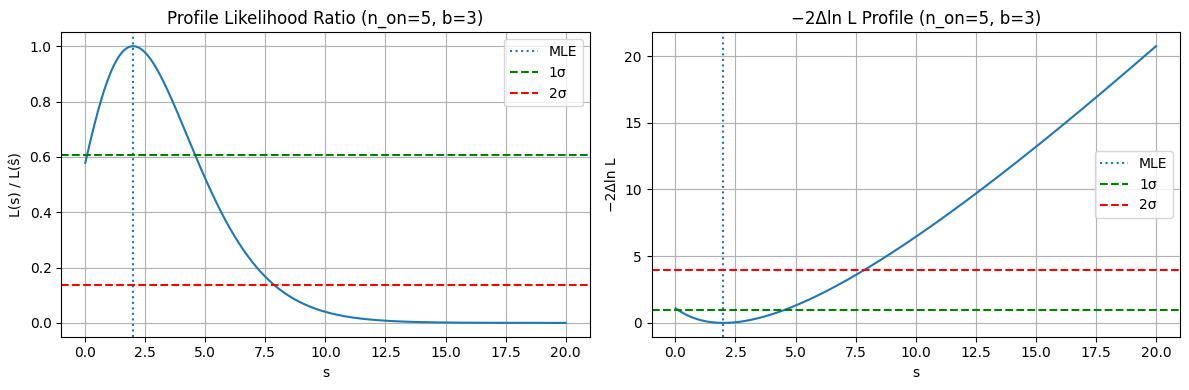

In [6]:
n_on, b = 5, 3
s_hat = max(0, n_on - b)

#Finding Upper Limit
ul = upper_limit(n_on, b, 5)

print(f"\nn_on={n_on}, b={b} | excess={s_hat:.1f}")
print(f"  5σ upper limit: {ul:.3f}")

#Plotting Likelihood Profile
plot_profile(n_on, b)

For the second case, given 
<br>
$ n_{on} = 5, n_{bkg} = 3 \implies \text{Excess}, \hat{s} = 5-3 = 2$


Now, the significance is $ \sigma = \sqrt{TS} = \sqrt{\Delta C(s)}$


We have, 
$$
    C(\hat{s}=7)=-2\ln(\mathcal{L}(2)) = -6.09 \text{  and } C(s=0)=-2\ln(\mathcal{L}(0)) = -4.986
$$

$$
\therefore \Delta C = 1.104 \implies \sigma = \sqrt{1.104} = 1.05
$$

From the Likelihood Profile plot we have the 5-$\sigma$ upper limit is 22.682.

---

## Question 2 - WStats

In this case, we have a distribution for the signal as well as the signal. We have obtained $n_{on}$(N) signals for couts when the detector points to the source and $n_{bkg}$(n) is the count from a region of no source and we are given a vaue $\alpha = \frac{n_{on(bkg}}{n_{off}}$.

In this scenerio we have 2 poissonian distributions $n_{on} \approx P(s+b)$ and $n_{off} \approx P(b/\alpha) $

Therefore, our :ikelihood Profile is ,
$$
    \mathcal{L}(s,b) = \frac{(s+b)^N e^{-(s+b)}}{N!}  \frac{(b/ \alpha)^N e^{-b/ \alpha}}{n!} \\
    \implies \ln{\mathcal{L}(s,b)} = N\ln(s+b) - (s+b) - \ln N! + n\ln \frac{b}{\alpha} - \frac{b}{\alpha} - \ln n! 
$$
For the estimators we have, 
$$
    \partial_s(\ln\mathcal{L})=0 \\
    \frac{N}{s+b} - 1 = 0 \\
    \implies \hat{s}= N - \hat{b}
$$
and 
$$
    \partial_b(\mathcal{L}) = 0 \\
    \implies \frac{N}{s+b} - 1 + \frac{n/\alpha}{b/ \alpha} - \frac{1}{\alpha} = 0 
$$
Using the previous result of $\hat{s}= N - \hat{b}$,
$$

    \implies \hat{b} = \alpha n
$$
Now, to define $\lambda$ we need to obtain $\hat{b}(s)$
$$
    \partial_b(\mathcal{L}) = 0 \\
    \implies \frac{N}{s+b} - 1 + \frac{n 1/\alpha}{b/ \alpha} - \frac{1}{\alpha} = 0 \\
    \implies \frac{N}{s+b} = \frac{b\alpha - n \alpha +b}{\alpha b} \\
    \implies (1+\alpha)b^2 + [ (\alpha +1) s - \alpha (n +N)]b - ns\alpha = 0
$$
Now, using the quadratic solution and considering only the positive root.
$$
    \hat{b}(s) = \frac{(n+N) - s(1+1/\alpha) + \sqrt{ (s(1+ 1/\alpha) - (n+N))^2 + 4ns(1+ 1/\alpha)}}{2(1+ 1/\alpha)}
$$

Now, let us define $\lambda = \frac{\mathcal{L}(s,\hat{b}(s))}{\mathcal{L}(\hat{s},\hat{b})} \implies TS = -2\ln\lambda$

And we have Significance, $\sigma = \sqrt{TS}$

#### Estimators and TS_WStats

In [7]:
#For finding b_hat
def b_hat_wstat(s, N, n, alpha):
    """Conditional MLE of b given s (WStat)."""
    A = 1 + 1/alpha
    term = (N + n) - A*s
    # correct discriminant: term^2 + 4*(n/alpha)*s  [not 4*A*n*s]
    return (term + np.sqrt(term**2 + 4*(n/alpha)*s)) / (2*A)


#Finding the log of the WStats
def logL_wstat(s, b, N, n, alpha):
    """WStat log-likelihood (up to additive constants from factorials)."""
    return N*np.log(s + b) - (s + b) + n*np.log(b/alpha) - b/alpha


#Finding the MLE of the WStats
def mle_wstat(N, n, alpha):
    """Global MLE: s_hat, b_hat."""
    s_hat = max(0.0, N - alpha*n)
    b_hat = alpha*n
    return s_hat, b_hat


#For the TS of the WStats
def TS_wstat(s, N, n, alpha, logL_max):
    b = b_hat_wstat(s, N, n, alpha)
    return -2 * (logL_wstat(s, b, N, n, alpha) - logL_max)

#### Finding the Likelihood values

In [8]:
def print_likelihood(s, b, N, n, alpha, label=""):
    import math as m
    A = (s + b)**N * m.exp(-(s + b)) / m.factorial(N)
    B = (b/alpha)**n * m.exp(-(b/alpha)) / m.factorial(n)
    L = A * B
    tag = f" [{label}]" if label else ""
    print(f"  s={s}, b={b:.4f}{tag}")
    print(f"  A = {A:.4e},  B = {B:.4e},  L(s,b) = {L:.4e}")


#### Confidence Levels

In [9]:
def confidence_interval_wstat(N, n, alpha, sigma):
    s_hat, bh = mle_wstat(N, n, alpha)
    logL_max = logL_wstat(s_hat, bh, N, n, alpha)

    cl = norm.cdf(sigma) - norm.cdf(-sigma)
    deltaC_target = chi2.ppf(cl, df=1)   # correct chi2 threshold

    def f(s):
        return TS_wstat(s, N, n, alpha, logL_max) - deltaC_target

    # left root
    s_left = None
    if s_hat > 0 and f(1e-10) * f(s_hat) < 0:
        s_left = root_scalar(f, bracket=[1e-10, s_hat], method='brentq').root
    else:
        s_left = 0.0

    # right root
    s_max = max(s_hat + 1, 1.0)
    while f(s_hat) * f(s_max) > 0:
        s_max *= 2
        if s_max > 1e6:
            raise RuntimeError("Right root not found")
    s_right = root_scalar(f, bracket=[s_hat, s_max], method='brentq').root

    return s_left, s_right


#### Finding Upper Limit

In [10]:
def upper_limit_wstat(N, n, alpha, sigma_ul):
    s_hat, bh = mle_wstat(N, n, alpha)
    logL_max = logL_wstat(s_hat, bh, N, n, alpha)

    cl = norm.cdf(sigma_ul) - norm.cdf(-sigma_ul)
    deltaC_target = chi2.ppf(cl, df=1)   # same chi2 threshold, one-sided by construction

    def f(s):
        return TS_wstat(s, N, n, alpha, logL_max) - deltaC_target

    s_max = max(s_hat + 1, 1.0)
    while f(s_hat) * f(s_max) > 0:
        s_max *= 2
        if s_max > 1e6:
            raise RuntimeError("Upper limit root not found")
    return root_scalar(f, bracket=[s_hat, s_max], method='brentq').root

#### Plotting the Profile Likelihood

In [11]:
def plot_profile_wstat(N, n, alpha):
    s_hat, bh = mle_wstat(N, n, alpha)
    logL_max = logL_wstat(s_hat, bh, N, n, alpha)

    s_vals = np.linspace(0.01, 25, 5000)
    ts_vals = np.array([TS_wstat(s, N, n, alpha, logL_max) for s in s_vals])

    # profile likelihood ratio
    plr = np.exp(-0.5 * ts_vals)

    thr_1s = chi2.ppf(norm.cdf(1) - norm.cdf(-1), df=1)
    thr_2s = chi2.ppf(norm.cdf(2) - norm.cdf(-2), df=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # left: profile likelihood ratio
    axes[0].plot(s_vals, plr)
    axes[0].axvline(s_hat, linestyle=':', label='MLE')
    axes[0].axhline(np.exp(-thr_1s/2), linestyle='--', color='green', label='1σ')
    axes[0].axhline(np.exp(-thr_2s/2), linestyle='--', color='red',   label='2σ')
    axes[0].set_xlabel('s')
    axes[0].set_ylabel('L(s, b̂(s)) / L(ŝ, b̂)')
    axes[0].set_title(f'Profile Likelihood Ratio (N={N}, n={n})')
    axes[0].legend()
    axes[0].grid()

    # right: -2 delta ln L
    axes[1].plot(s_vals, ts_vals)
    axes[1].axvline(s_hat, linestyle=':', label='MLE')
    axes[1].axhline(thr_1s, linestyle='--', color='green', label='1σ')
    axes[1].axhline(thr_2s, linestyle='--', color='red',   label='2σ')
    axes[1].set_xlabel('s')
    axes[1].set_ylabel('−2Δln L')
    axes[1].set_title(f'−2Δln L Profile (N={N}, n={n})')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

**CASE 1 - $N_{on} = 10$ and $N_{bkg}=3$**

N=10, n=6, alpha=0.5
  excess (s_hat) = 7.000

Likelihood at MLE:
  s=7.0, b=3.0000 [MLE]
  A = 1.2511e-01,  B = 1.6062e-01,  L(s,b) = 2.0096e-02

Likelihood at s=0 (null):
  s=0, b=5.3333 [s=0]
  A = 2.4773e-02,  B = 4.7683e-02,  L(s,b) = 1.1813e-03

  1σ CI: [4.142, 9.494]
  2σ CI: [1.044, 14.234]


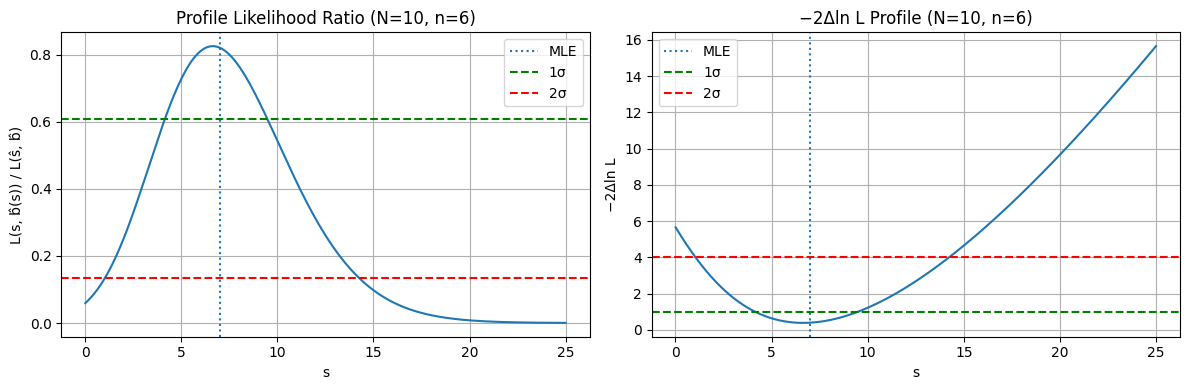

In [12]:
N, n, alpha = 10, 6, 0.5
s_hat, bh = mle_wstat(N, n, alpha)
print(f"N={N}, n={n}, alpha={alpha}")
print(f"  excess (s_hat) = {s_hat:.3f}")

# explicit likelihood at MLE and at s=0 (same diagnostic you had before)
print("\nLikelihood at MLE:")
print_likelihood(s_hat, bh, N, n, alpha, label="MLE")
b_null = b_hat_wstat(0, N, n, alpha)
print("\nLikelihood at s=0 (null):")
print_likelihood(0, b_null, N, n, alpha, label="s=0")

ci_1s = confidence_interval_wstat(N, n, alpha, 1)
ci_2s = confidence_interval_wstat(N, n, alpha, 2)
print(f"\n  1σ CI: [{ci_1s[0]:.3f}, {ci_1s[1]:.3f}]")
print(f"  2σ CI: [{ci_2s[0]:.3f}, {ci_2s[1]:.3f}]")

plot_profile_wstat(N, n, alpha)

For the case 1 we have, $n_{on}=N=10, n_{off}=n=6, \alpha=0.5$

$\therefore \text{Excess}, \hat{s} = 10 - 6/2 = 7$

Now, Significance, $\sigma = \sqrt{-2\ln(\frac{0.00118}{0.059})} = 2.38$

We have also obtained the confidence intervals using the likelhood profile, 1-$\sigma$ is [4.142, 9.494] and 2-$\sigma$ = [1.044, 14.234]

**CASE 2 - $N_{on} = 5$ and $N_{off}=6$ and $\alpha=1/2$**


N=5, n=6, alpha=0.5
  excess (s_hat) = 2.000

Likelihood at MLE:
  s=2.0, b=3.0000 [MLE]
  A = 1.7547e-01,  B = 1.6062e-01,  L(s,b) = 2.8184e-02

Likelihood at s=0 (null):
  s=0, b=3.6667 [s=0]
  A = 1.4118e-01,  B = 1.4114e-01,  L(s,b) = 1.9926e-02

  5σ upper limit: 22.695


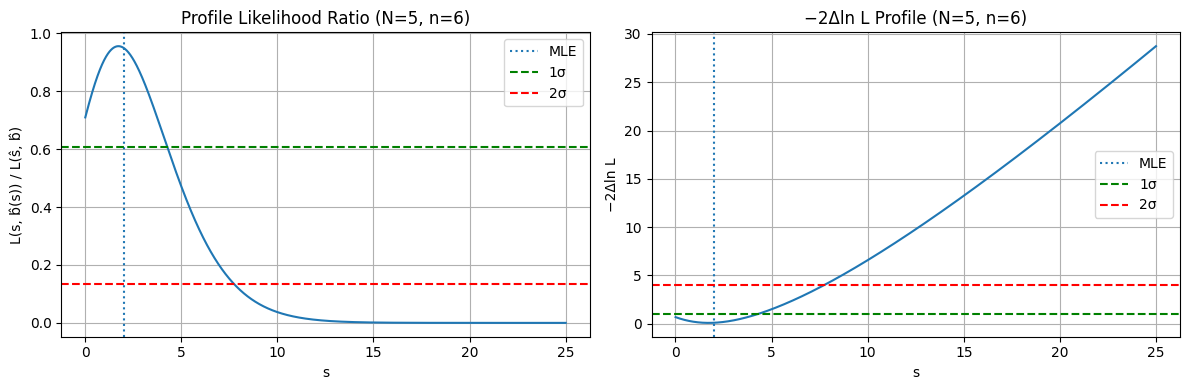

In [13]:
N, n, alpha = 5, 6, 0.5
s_hat, bh = mle_wstat(N, n, alpha)
print(f"\nN={N}, n={n}, alpha={alpha}")
print(f"  excess (s_hat) = {s_hat:.3f}")

print("\nLikelihood at MLE:")
print_likelihood(s_hat, bh, N, n, alpha, label="MLE")
b_null = b_hat_wstat(0, N, n, alpha)
print("\nLikelihood at s=0 (null):")
print_likelihood(0, b_null, N, n, alpha, label="s=0")

ul = upper_limit_wstat(N, n, alpha, 5)
print(f"\n  5σ upper limit: {ul:.3f}")

plot_profile_wstat(N, n, alpha)

For the case 2 we have, $n_{on}=N=5, n_{off}=n=6, \alpha=0.5$

$\therefore \text{Excess}, \hat{s} = 5 - 6/2 = 2$

Now, Significance, $\sigma = \sqrt{-2\ln(\frac{0.0199}{0.0282})} = 0.697$

We have also obtained the 5 $-\sigma$ upper limit from the likelhood profile as 22.695

### Difference of the two likelihoods in Cstats and Wstats

In CStats the background is known and all the statistical uncertainity from the poissonian distrbution is attributed to the source signal.
$$
     \sigma^2 \approx n_{on} 
$$ 

In WStats, the background obtained from a no source region also has a poissonian distribution which leads to more statistical uncertainity.

$$ 
    \sigma^2 \approx n_{on} + \alpha^2 n_{off} 
$$

This means WStat significances are generally lower and confidence intervals are wider for the same observed excess — as we can see comparing the two case-1 results: CStat gives $\sim 3.17 \sigma$ while WStat gives $\sim 2.38 \sigma$ for essentially the same excess of 7 counts.

Therefore, in a real case of gamma-ray observation where the background is usally not known, CStats can lead to overestimated significance.

---

## Question - 3

#### Defining a time Series and Gaussian Signal

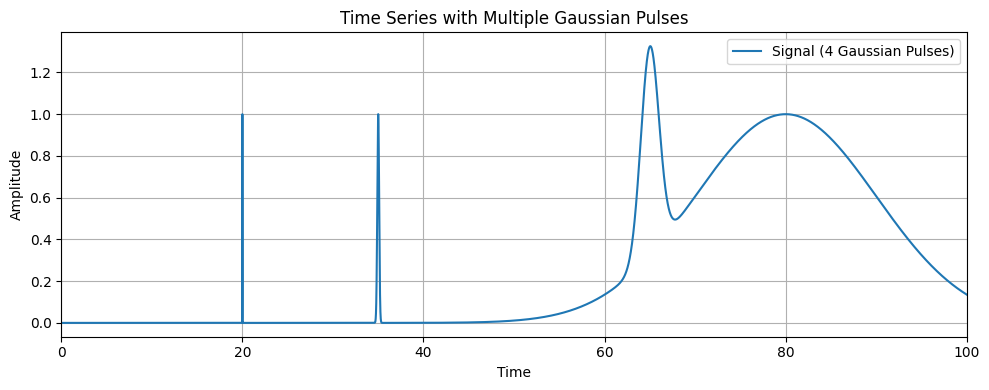

In [14]:
#Defining Time Series
t = np.linspace(0, 100, 100000)   # 0 to 100 as you said
dt = t[1] - t[0]



#Defining Signal
def gaussian(t, t0, sigma, A=1):
    return A * np.exp(-(t - t0)**2 / (2 * sigma**2))

sigmas  = [0.01, 0.1, 1, 10]
centers = [20, 35, 65, 80]   # shifted to fit 0–100 range

signal = np.zeros_like(t)
for s, c in zip(sigmas, centers):
    signal += gaussian(t, c, s)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Signal (4 Gaussian Pulses)')
plt.title('Time Series with Multiple Gaussian Pulses')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.xlim(0, 100)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Defining the Top-Hat Kernel

In [15]:
def make_kernel(R, dt):
    t_k = np.arange(-R, R + dt, dt)
    kernel = np.where(np.abs(t_k) <= R, 1.0, 0.0)
    # normalize as a density: integral = sum * dt = 1
    kernel = kernel / (np.sum(kernel) * dt)
    return kernel

#### Convolution of the Signal with 4 different radii

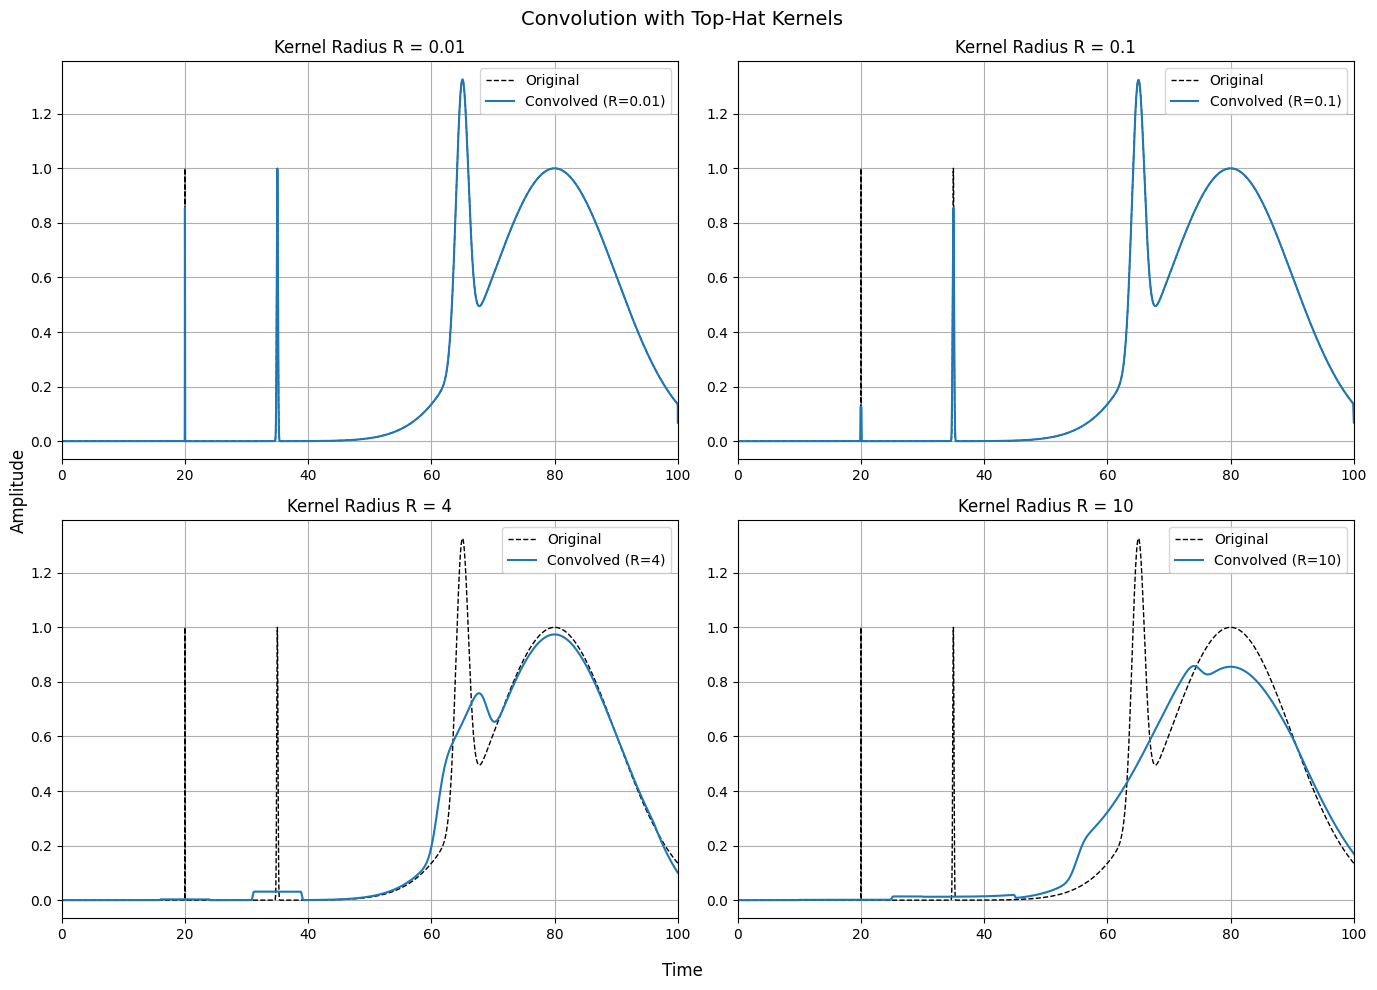

In [16]:
#Defining the radii for the kernels and performing convolution
radii = [0.01, 0.1, 4, 10]

# Convolve signal with each kernel and store results
convolved_signals = []
for R in radii:
    kernel = make_kernel(R, dt)
    conv = np.convolve(signal, kernel * dt, mode='same')  # * dt for proper integral
    convolved_signals.append(conv)

# Plotting the results
# x-axis clip: narrow kernels → zoom in on individual pulses, wide → full range
xlims = [(0, 100), (0, 100), (0, 100), (0, 100)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # no sharex: each panel clipped individually
axes = axes.flatten()

for ax, conv, R, xlim in zip(axes, convolved_signals, radii, xlims):
    ax.plot(t, signal, linestyle='--', color='black', linewidth=1.0, label='Original')
    ax.plot(t, conv, label=f'Convolved (R={R})')
    ax.set_title(f'Kernel Radius R = {R}')
    ax.set_xlim(*xlim)
    ax.grid()
    ax.legend()

fig.supxlabel('Time')
fig.supylabel('Amplitude')
fig.suptitle('Convolution with Top-Hat Kernels', fontsize=14)
plt.tight_layout()
plt.show()

In this question, we use a top-hat (boxcar) kernel defined as
$$
K(x) =
\begin{cases}
\frac{1}{2R}, & |x| \le R \\
0, & |x| > R
\end{cases}
$$

The convolution of the signal with this kernel is given by
$$
(f*K)(x)= \frac{1}{2R} \int_{x-R}^{x+R} f(t)\,dt
$$

This corresponds to taking a moving average of the signal over a window of width $2R$. As a result, the effect of the kernel on the signal depends strongly on how the kernel radius compares to the intrinsic width of the Gaussian pulses.

Based on this, we expect:

- Kernel radius $\approx$ Gaussian width $\implies$ the peak is preserved while noise is reduced.
- Kernel radius $\ll$ Gaussian width $\implies$ noise remains dominant and the peak is largely unaffected.
- Kernel radius $\gg$ Gaussian width $\implies$ the signal is significantly suppressed or flattened.

We consider Gaussian pulses with widths $\sigma = [0.01, 0.1, 1, 10]$ and kernel radii $R = [0.01, 0.1, 4, 10]$. From the resulting plots:

- For $R = 0.01$, only the $\sigma = 0.01$ peak is slightly suppressed, while broader peaks remain unchanged.
- For $R = 0.1$, the $\sigma = 0.01$ peak is strongly suppressed, the $\sigma = 0.1$ peak is slightly suppressed, and wider peaks remain the same.
- For $R = 4$, the $\sigma = 0.01$ and $0.1$ peaks are almost completely flattened, while the $\sigma = 1$ and $10$ peaks are significantly suppressed.
- For $R = 10$, the $\sigma = 0.01$, $0.1$, and $1$ peaks are nearly flattened, and even the $\sigma = 10$ peak is noticeably reduced.

These results demonstrate that detetion of a signal is highly sensitive to the choice of kernel radius. Optimal detection occurs when the kernel scale is comparable to the width of the signal. If the kernel is too small, it fails to suppress noise effectively, while if it is too large, it washes out the signal. This highlights the importance of scale matching in convolution-based detection methods.

#### FFT on the Signal and Kernel

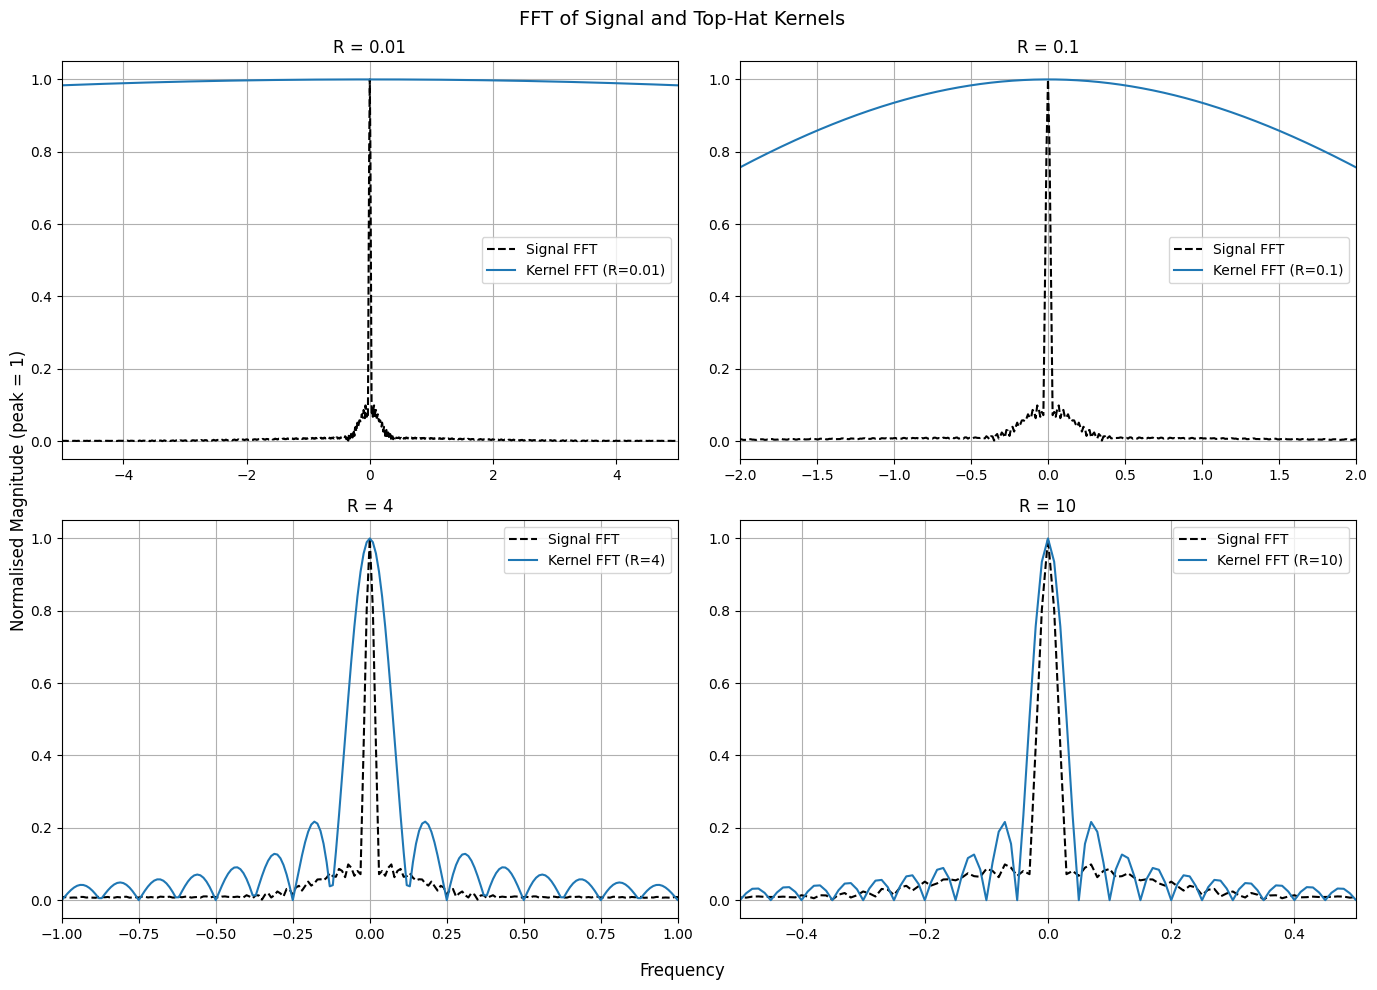

In [19]:
N_pts = len(t)

#FFt on Signal
freq         = np.fft.fftfreq(N_pts, dt)
freq_shifted = np.fft.fftshift(freq)

fft_signal_shifted = np.fft.fftshift(np.fft.fft(signal))


#FFT on Kernels
fft_kernels = []
for R in radii:
    kernel = make_kernel(R, dt)
    fft_k  = np.fft.fft(kernel * dt, n=N_pts)   # include dt so FFT ≈ continuous FT
    fft_kernels.append(np.fft.fftshift(fft_k))


#Normalizing the Plots
def normalize_by_peak(arr):
    return np.abs(arr) / np.max(np.abs(arr))


#Plotting them based on radii
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

freq_xlims = [
    (-5, 5),
    (-2, 2),
    (-1, 1),
    (-0.5, 0.5)
]

for ax, R, fft_k, xlim in zip(axes, radii, fft_kernels, freq_xlims):
    ax.plot(freq_shifted, normalize_by_peak(fft_signal_shifted),
            linestyle='--', color='black', label='Signal FFT')
    ax.plot(freq_shifted, normalize_by_peak(fft_k),
            label=f'Kernel FFT (R={R})')
    ax.set_title(f'R = {R}')
    ax.set_xlim(*xlim)
    ax.grid()
    ax.legend()

fig.supxlabel('Frequency')
fig.supylabel('Normalised Magnitude (peak = 1)')
fig.suptitle('FFT of Signal and Top-Hat Kernels', fontsize=14)
plt.tight_layout()
plt.show()

The FFT of the signal and kernel takes us to the frequency space, which allows a frequency interpretation of the convolution process. 
<br>
The FFT of the signal (which is a sum of gaussians) gives us a gaussian but here the smaller width guassians give the higher frequency components. 

The FFt of the kernel gives us a sinc function - 
$$
    \tilde{K}(k) \propto \frac{\sin(kR)}{kR}
$$
Here, we can note that the top hat kernal acts as a low pass filter such that $ k_{cut-off} \sim \frac{1}{R} $ - 
* Small R $\implies$ we have a wider spectrum, where higher frequencies are allowed to pass and the sharper features are presereved.
* Large R $\implies$ we have a narrow spectrum and it cuts off the higher frequencies earlier and only the low frequencies survive.|

#### FFT of Convoluted Signal

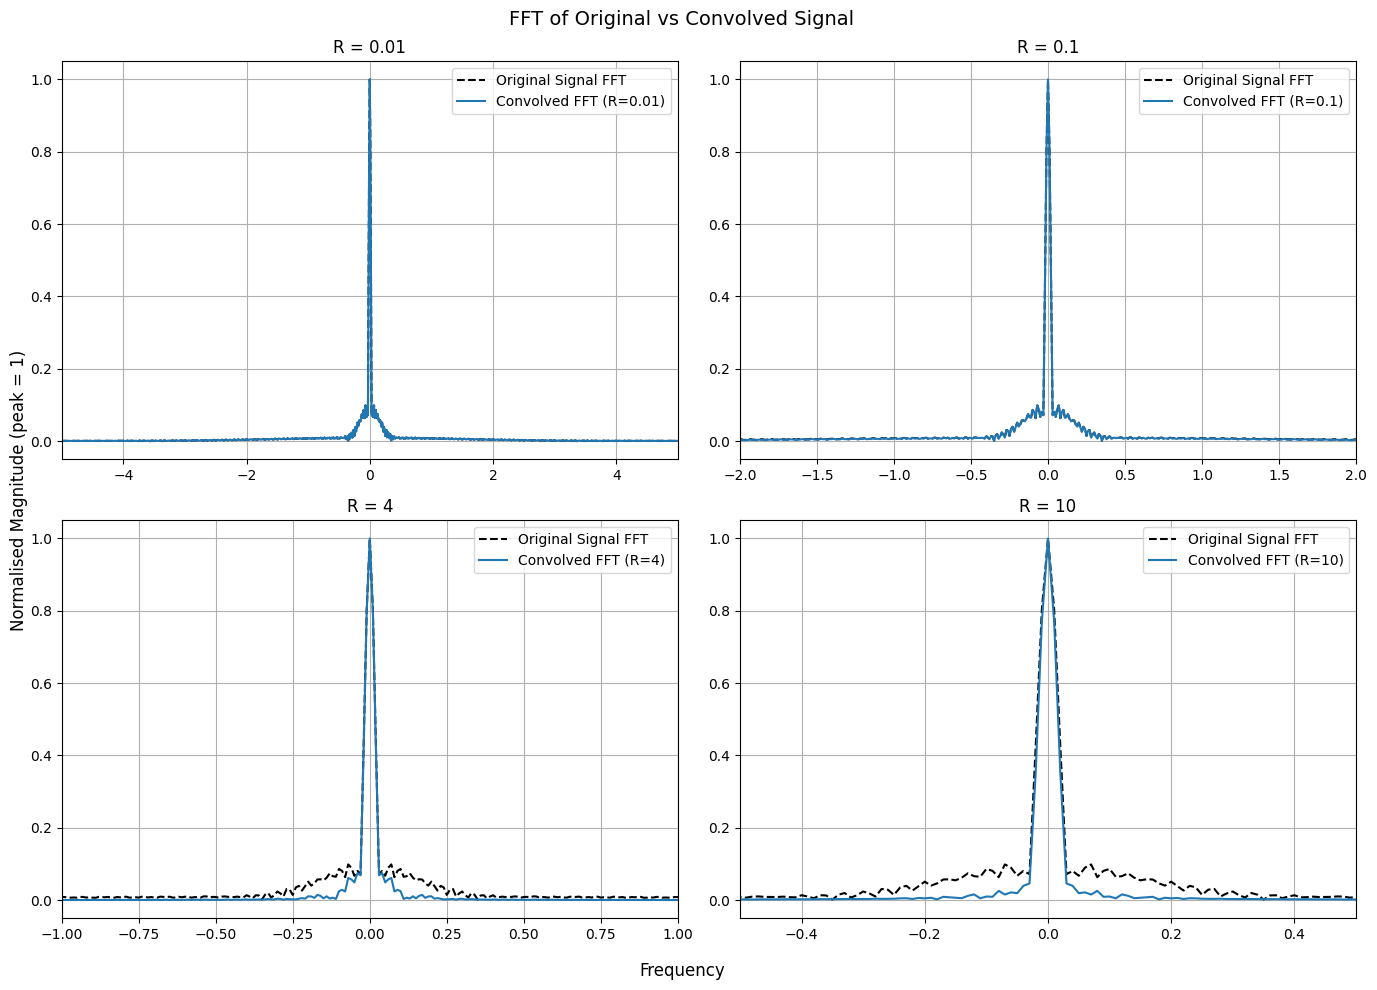

In [21]:
# FFT of convolved signals
fft_convolved = []
for conv in convolved_signals:
    fft_c = np.fft.fftshift(np.fft.fft(conv))
    fft_convolved.append(fft_c)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, R, fft_c, xlim in zip(axes, radii, fft_convolved, freq_xlims):
    ax.plot(freq_shifted, normalize_by_peak(fft_signal_shifted),
            linestyle='--', color='black', label='Original Signal FFT')
    ax.plot(freq_shifted, normalize_by_peak(fft_c),
            label=f'Convolved FFT (R={R})')
    ax.set_title(f'R = {R}')
    ax.set_xlim(*xlim)
    ax.grid()
    ax.legend()

fig.supxlabel('Frequency')
fig.supylabel('Normalised Magnitude (peak = 1)')
fig.suptitle('FFT of Original vs Convolved Signal', fontsize=14)
plt.tight_layout()
plt.show()

The convolution in real space corresponds to multiplication in the fourier space.
$$
    \mathcal{F}(f*K) = \mathcal{F}(f).\mathcal{F}(K)
$$
and from the above plot we can conclude -
* The central peak, which corresponds to low frequency, remains unchanged, which is to be expected as Top-Hat kernal acts like a low pass filter.
* For the R=0.01 kernel , we can note that most of the frequencies are still there as we have a wider spectrum and hence the kernal does not significantly filter the spectrum.
* For the R=4 case we can note that the higher frequencies around the peak have been filtered out as the kernel is now starting to be an effective low pass filter.
* For R=10, we can note string suppressions of the higher frequencies.


Therefore, narrow Gaussian peaks (which contain significant high-frequency components) are suppressed for large kernel radii, while broader peaks (dominated by low frequencies) are preserved. Thus, the FFT provides a frequency-space explanation for the scale-dependent smoothing observed in real space.

---

## Question - 4

#### Adding a slow-varying background $0.3 + 0.1 \sin(0.05t)$

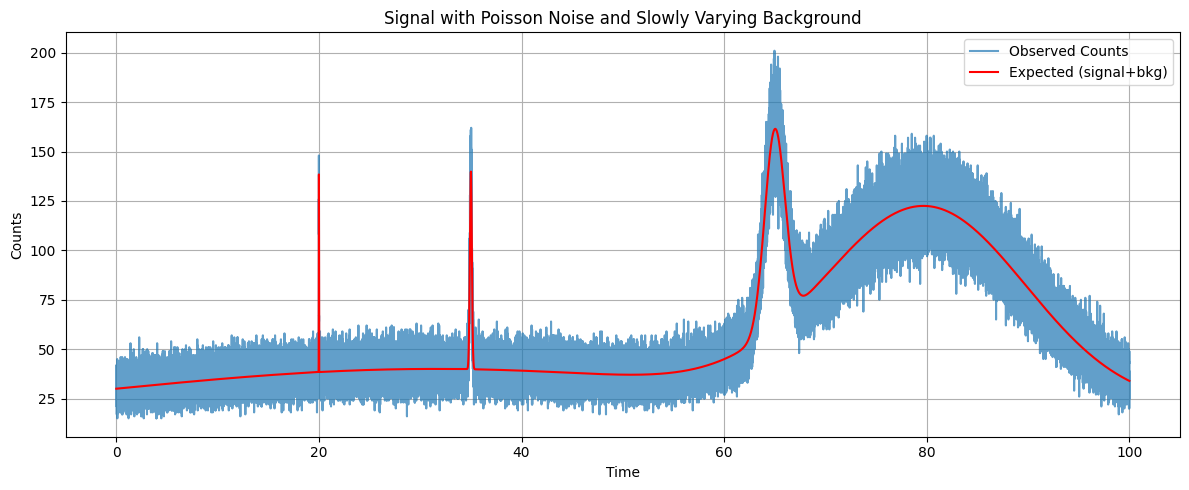

In [22]:
# Simulating Poisson Noise with Slowly Varying Background
scale = 100  # counts per unit amplitude

#Defining teh slow-vcarying Background
background = 0.3 + 0.1 * np.sin(0.05 * t)

expected_counts = (signal + background) * scale 

noisy_counts = np.random.poisson(expected_counts).astype(float)

plt.figure(figsize=(12, 5))
plt.plot(t, noisy_counts, drawstyle='steps-mid', alpha=0.7, label='Observed Counts')
plt.plot(t, expected_counts, color='red', linewidth=1.5, label='Expected (signal+bkg)')
plt.xlabel('Time')
plt.ylabel('Counts')
plt.title('Signal with Poisson Noise and Slowly Varying Background')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### Convoluting the Signal for the same Top-Hat Kernel

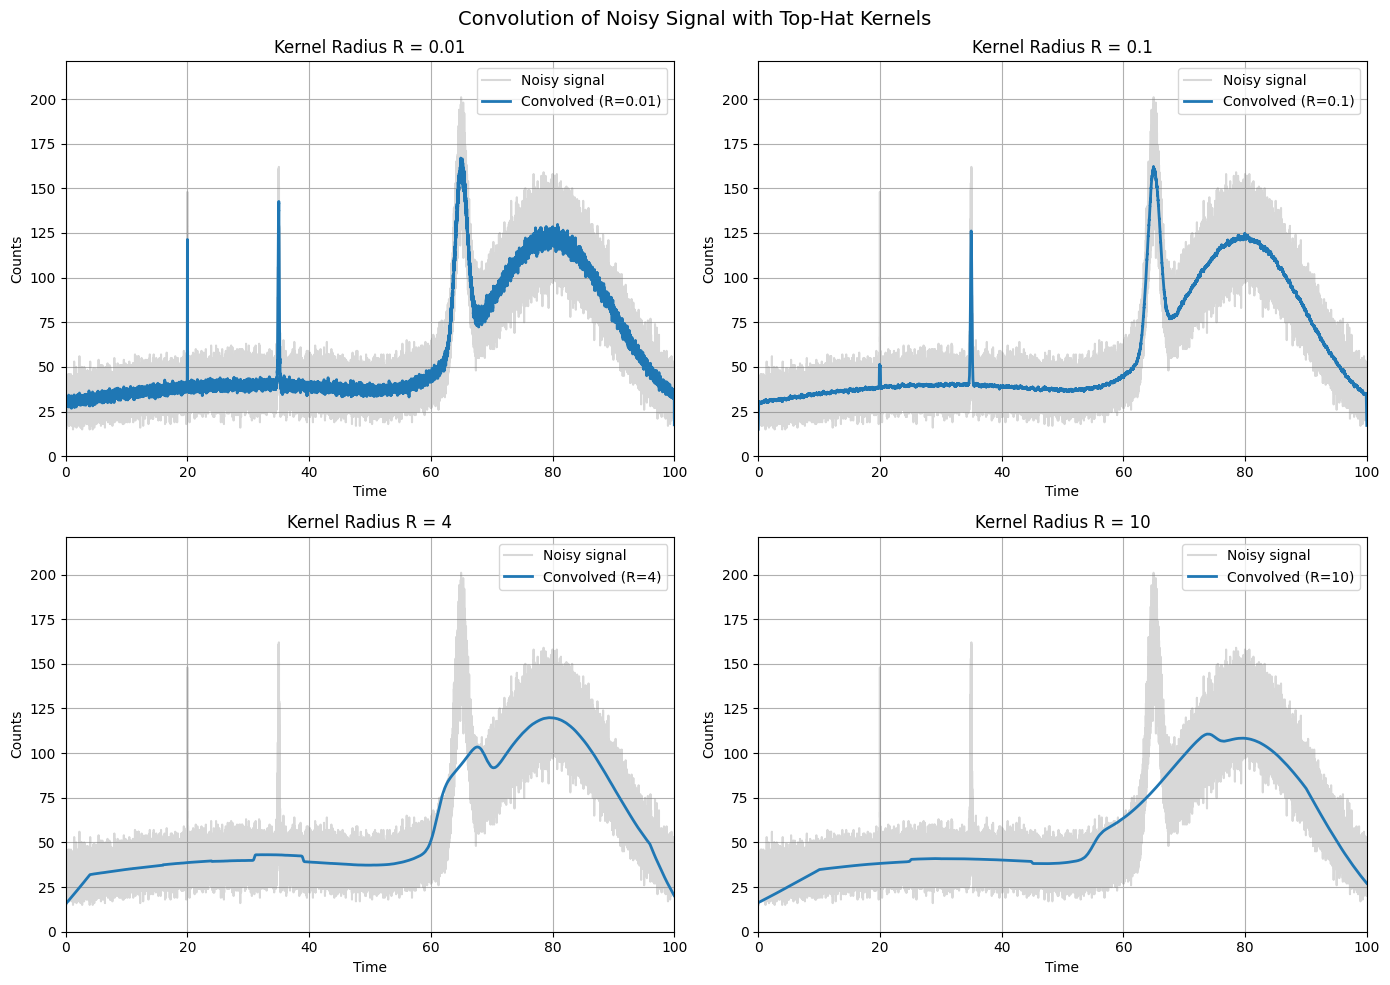

In [23]:
noisy_convolved = []
for R in radii:
    kernel = make_kernel(R, dt)
    conv = np.convolve(noisy_counts, kernel * dt, mode='same')  # dt for proper integral
    noisy_convolved.append(conv)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, R, conv in zip(axes, radii, noisy_convolved):
    ax.plot(t, noisy_counts, alpha=0.3, color='gray', drawstyle='steps-mid', label='Noisy signal')
    ax.plot(t, conv, linewidth=2, label=f'Convolved (R={R})')
    ax.set_title(f'Kernel Radius R = {R}')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, np.max(noisy_counts) * 1.1)
    ax.set_xlabel('Time')
    ax.set_ylabel('Counts')
    ax.grid()
    ax.legend()

fig.suptitle('Convolution of Noisy Signal with Top-Hat Kernels', fontsize=14)
plt.tight_layout()
plt.show()

In this question, we have added a slowly varying background that has added a low frequency components and shifted the baseline of the original signal and can also hide the broader signals. 

The poissonian background added has added a random fluctiation in each bin as $ \sigma \sim \sqrt{N} $, which introduces high frequency fluctuations and makes the peak harder to distinguish.

With the convolution of the signal with the kernel we can note that the poissonian background is significantly reduced, as the fluctuations are random and averge out to zero. However, we can also note that the small kernel, R=0.01, fails to suppress the noise compared to the other 3 radii. As we have seen in the previous case we can also note that the larger radius kernels also wash out the sharper signals . 

Therefore, the optimal kernal radius needs to be of the scale of the signal and also large enough to supress the noise. Hence, the kernel radius now depends not only on the signal peak and width but also the signal-to-noise ratio.

#### FFT of the Signal and Kernel

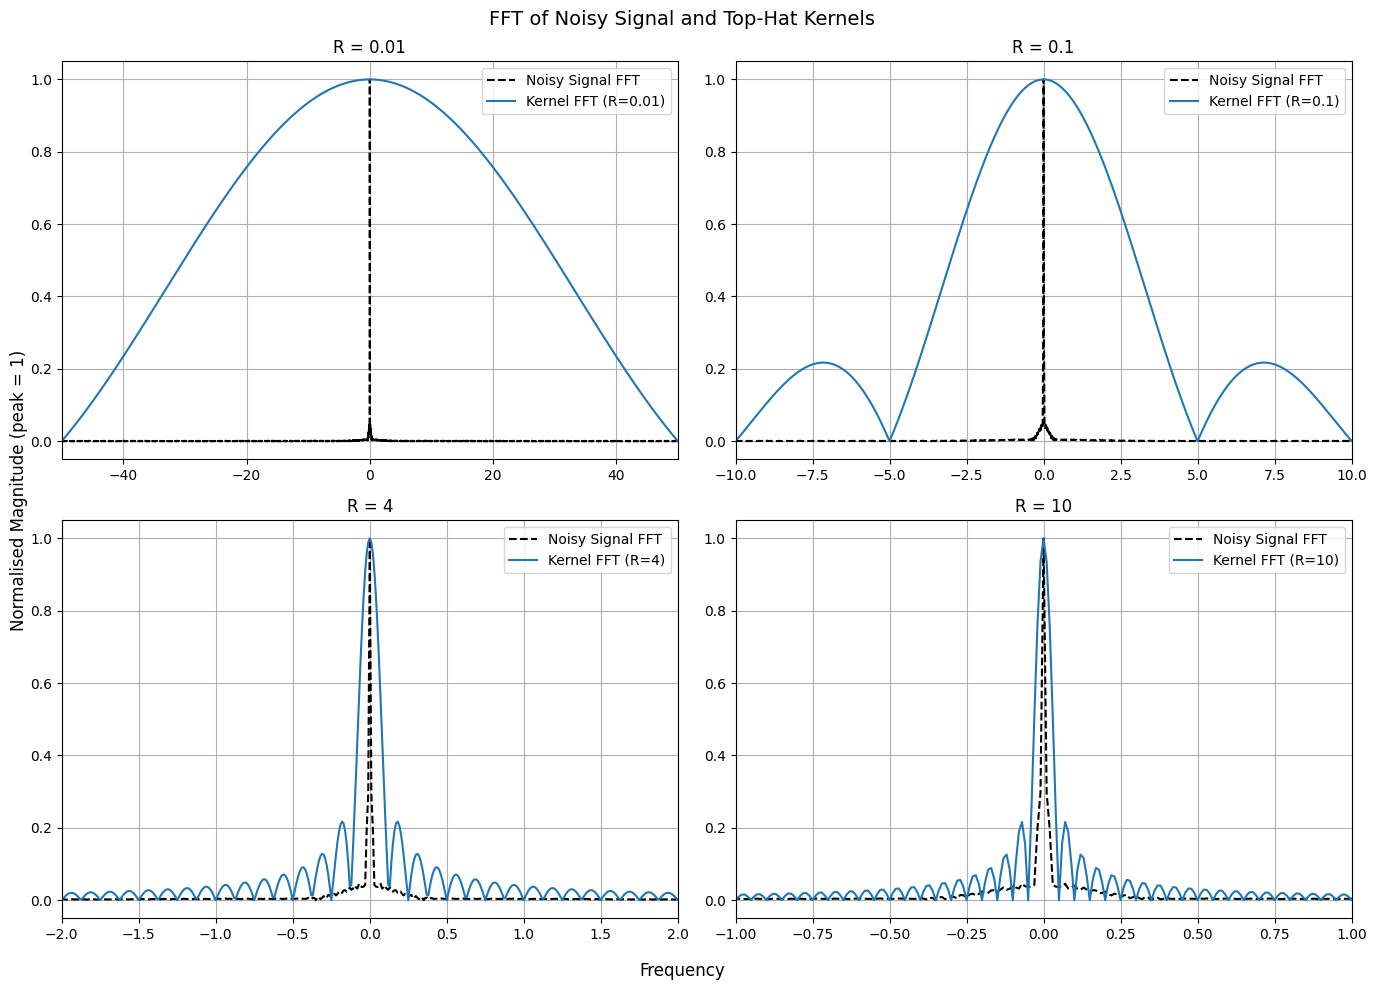

In [24]:
N_pts = len(t)
freq         = np.fft.fftfreq(N_pts, dt)
freq_shifted = np.fft.fftshift(freq)

fft_noisy_shifted = np.fft.fftshift(np.fft.fft(noisy_counts))

fft_kernels_noisy = []
for R in radii:
    kernel = make_kernel(R, dt)
    fft_k  = np.fft.fft(kernel * dt, n=N_pts)
    fft_kernels_noisy.append(np.fft.fftshift(fft_k))

def normalize_by_peak(arr):
    return np.abs(arr) / np.max(np.abs(arr))

# same per-panel freq xlims as Q3
freq_xlims = [
    (-50,  50),
    (-10,  10),
    (-2,    2),
    (-1,    1),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, R, fft_k, xlim in zip(axes, radii, fft_kernels_noisy, freq_xlims):
    ax.plot(freq_shifted, normalize_by_peak(fft_noisy_shifted),
            linestyle='--', color='black', label='Noisy Signal FFT')
    ax.plot(freq_shifted, normalize_by_peak(fft_k),
            label=f'Kernel FFT (R={R})')
    ax.set_title(f'R = {R}')
    ax.set_xlim(*xlim)
    ax.grid()
    ax.legend()

fig.supxlabel('Frequency')
fig.supylabel('Normalised Magnitude (peak = 1)')
fig.suptitle('FFT of Noisy Signal and Top-Hat Kernels', fontsize=14)
plt.tight_layout()
plt.show()

#### FFT of Convoluted Signal

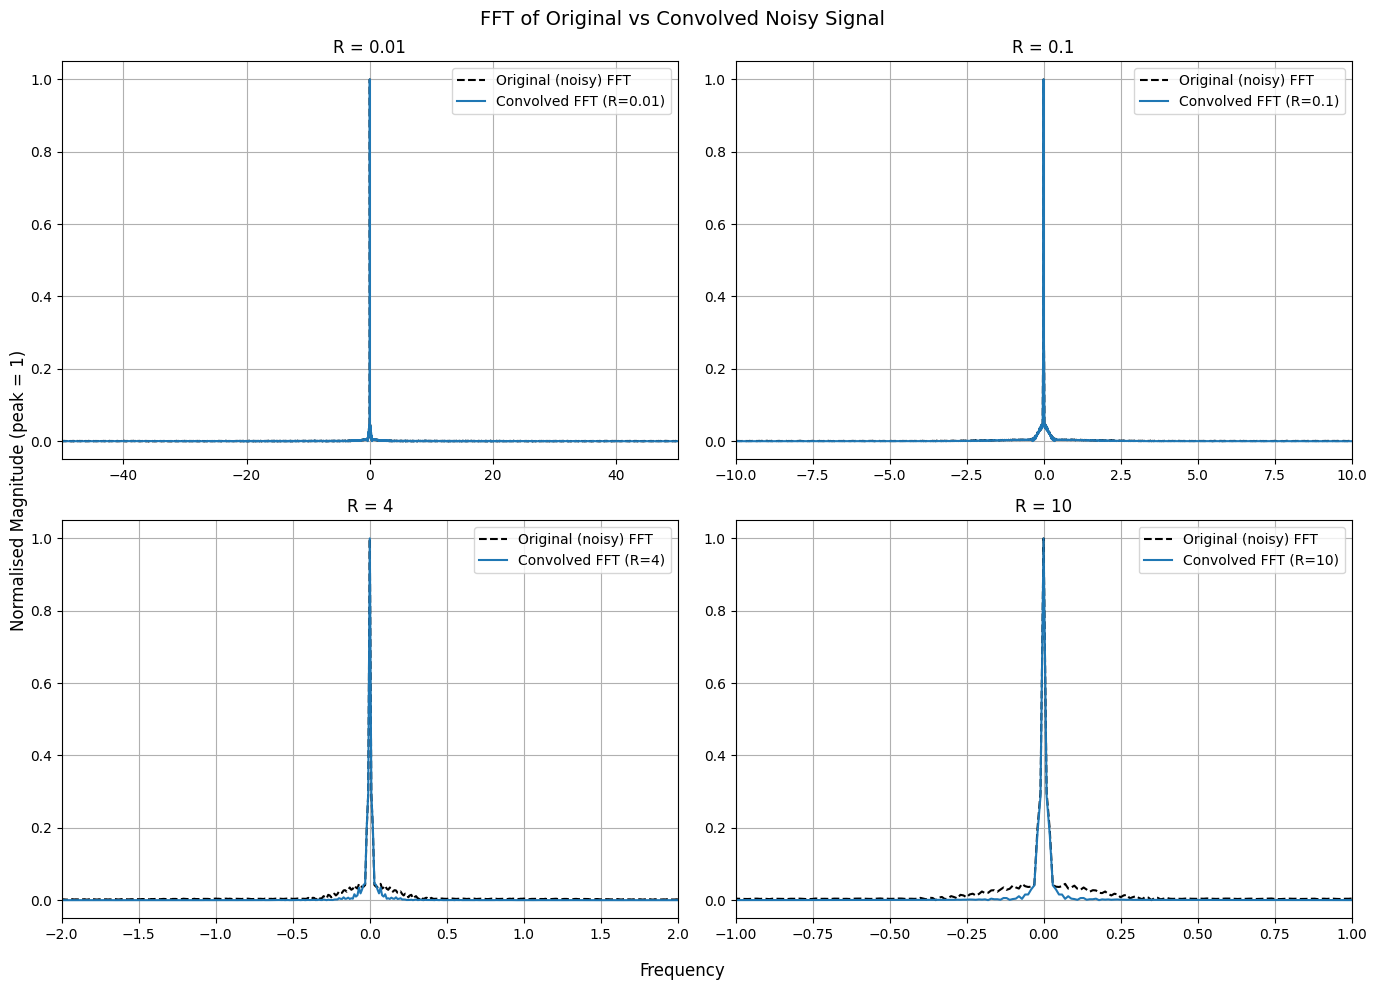

In [25]:
fft_convolved = []
for conv in noisy_convolved:
    fft_c = np.fft.fft(conv)
    fft_convolved.append(np.fft.fftshift(fft_c))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, R, fft_c, xlim in zip(axes, radii, fft_convolved, freq_xlims):
    ax.plot(freq_shifted, normalize_by_peak(fft_noisy_shifted),
            linestyle='--', color='black', label='Original (noisy) FFT')
    ax.plot(freq_shifted, normalize_by_peak(fft_c),
            label=f'Convolved FFT (R={R})')
    ax.set_title(f'R = {R}')
    ax.set_xlim(*xlim)
    ax.grid()
    ax.legend()

fig.supxlabel('Frequency')
fig.supylabel('Normalised Magnitude (peak = 1)')
fig.suptitle('FFT of Original vs Convolved Noisy Signal', fontsize=14)
plt.tight_layout()
plt.show()

In the FFT of the convoluted noisy signal we should note that -
- Gaussian signal still gives a gaussian in the frequency space
- The poissonian noise adds a flat power spectrum across all the frequencies, giving a constant noise floor in the frequency space.
- The slow varying background adds strong peaks around $\mu \approx 0$, this implies unlike the previous case where we the larger width gaussian signals in the $\mu \approx 0$ region, in this case the background masks the signal.


FFT allows to differentiate between these frequency compoenets and as the radius of the kernel increases and it suppresses the higher frequencies more strongly we can note that the FFT of the convoluted signal obtained is more similar to the gaussian signal (same as the previous, Q3, case).

---

## Question 5

In [1]:
#Relevant Pckages
import astropy.units as u
from astropy.coordinates import SkyCoord
from pathlib import Path

# Using GammaPy , adding all the relevant packages
from gammapy.data import Observation, FixedPointingInfo
from gammapy.datasets import MapDataset
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import (
    SkyModel,
    PowerLawSpectralModel,
    PointSpatialModel,
    GaussianSpatialModel,
    Models,
    FoVBackgroundModel,
)
from gammapy.visualization import plot_distribution


/Users/dikshitahazarika/miniforge3/envs/gammapy-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loading the IRFs

In [3]:
irf_path = Path.home() / "gammapy-datasets/2.0.1/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"
irfs = load_irf_dict_from_file(irf_path)
print("IRFs loaded:", list(irfs.keys()))

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


IRFs loaded: ['aeff', 'psf', 'edisp', 'bkg']


#### Establishing the Geometry and Observations

In [2]:
# Geometry
pointing = SkyCoord(0.0, 0.0, unit="deg", frame="galactic")

energy_axis = MapAxis.from_energy_bounds(
    1.0, 10.0, nbin=3, unit="TeV", name="energy"
)
energy_axis_true = MapAxis.from_energy_bounds(
    0.5, 20.0, nbin=10, unit="TeV", name="energy_true"
)

geom = WcsGeom.create(
    skydir=pointing,
    binsz=0.02,
    width=(5.0, 5.0),
    frame="galactic",
    axes=[energy_axis],
)

# Observation
pointing_info = FixedPointingInfo(fixed_icrs=pointing.icrs)

observation = Observation.create(
    obs_id=1,
    pointing=pointing_info,
    livetime=10.0 * u.hr,
    irfs=irfs,
)


NameError: name 'irfs' is not defined

#### Building the Dataset and the Model

In [ ]:
#Building a dataset
empty = MapDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
    name="simulated",
)

maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=2.5 * u.deg)

dataset = maker.run(empty, observation)
dataset = safe_mask.run(dataset, observation)
print("Dataset created.")



#Defining a power-law spectral model
def make_powerlaw():
    return PowerLawSpectralModel(
        index=2.5,
        amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
        reference=1.0 * u.TeV,
    )


# 4 sources: 1 point source + 3 Gaussians of increasing width
source_configs = [
    ("point",   PointSpatialModel(lon_0="0.0 deg",  lat_0="0.8 deg",  frame="galactic")),
    ("sig005",  GaussianSpatialModel(lon_0="0.8 deg",  lat_0="0.0 deg",  sigma="0.05 deg", frame="galactic")),
    ("sig010",  GaussianSpatialModel(lon_0="0.0 deg",  lat_0="-0.8 deg", sigma="0.10 deg", frame="galactic")),
    ("sig020",  GaussianSpatialModel(lon_0="-0.8 deg", lat_0="0.0 deg",  sigma="0.20 deg", frame="galactic")),
]

labels = ["Point source", "Gaussian σ=0.05°", "Gaussian σ=0.10°", "Gaussian σ=0.20°"]

# Create sky models for each source
sky_models = [
    SkyModel(spectral_model=make_powerlaw(), spatial_model=sm, name=name)
    for name, sm in source_configs
]

# Add a background model
bkg_model = FoVBackgroundModel(dataset_name="simulated")
dataset.models = Models(sky_models + [bkg_model])
print("Models assigned.")


Dataset created.
Models assigned.


#### Stimulating Counts

Counts simulated.


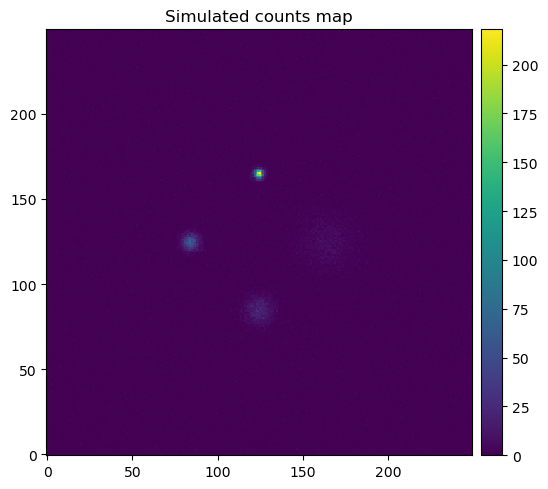

In [ ]:
dataset.fake(random_state=42)
print("Counts simulated.")

# quick sanity check — plot the counts map
fig, ax = plt.subplots(figsize=(6, 5))
dataset.counts.sum_over_axes().plot(ax=ax, cmap="viridis", add_cbar=True)
ax.set_title("Simulated counts map")
plt.tight_layout()
plt.savefig("counts_map.png", dpi=150, bbox_inches="tight")
plt.show()


#### ExcessMap Estimator

Excess map done for r = 0.05 deg
Excess map done for r = 0.1 deg
Excess map done for r = 0.2 deg
Excess map done for r = 0.4 deg
['npred', 'npred_excess', 'counts', 'ts', 'sqrt_ts', 'norm', 'norm_err']


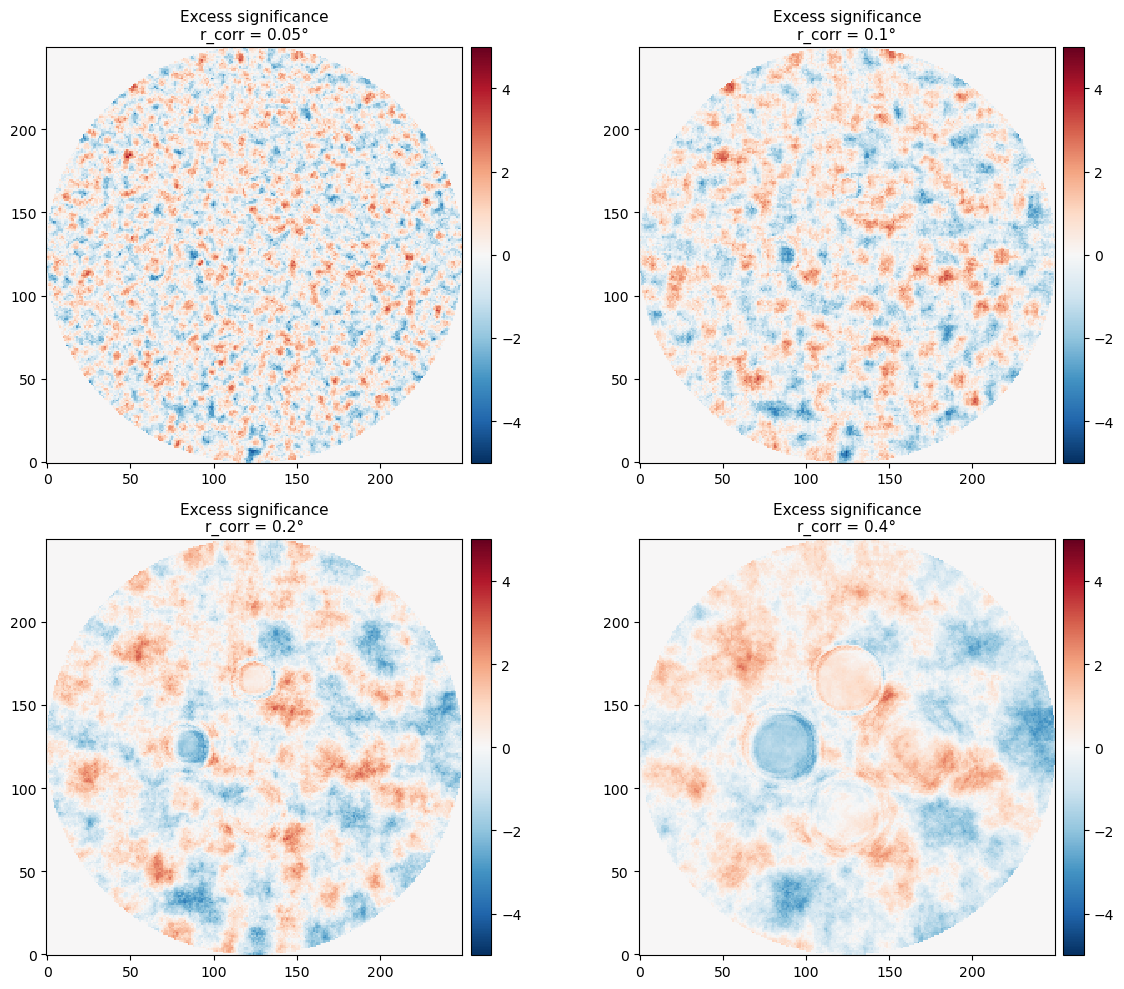

In [ ]:
# We use the same Top-hat kernel and define 4 different radii for the convolution, as we did in the 1D case.

correlation_radii = [0.05, 0.10, 0.20, 0.40]  # degrees

excess_results = {}
for r in correlation_radii:
    estimator = ExcessMapEstimator(
        correlation_radius=r * u.deg,
        selection_optional=[],
        n_sigma=3.0,
        n_sigma_ul=5.0,
    )
    excess_results[r] = estimator.run(dataset)
    print(f"Excess map done for r = {r} deg")

print(excess_results[0.05].available_quantities)

# Plot significance maps for each radius
# Plot significance maps for each radius (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, r in zip(axes, correlation_radii):
    sig_map = excess_results[r]["sqrt_ts"]
    sig_map.sum_over_axes().plot(
        ax=ax, cmap="RdBu_r", vmin=-5, vmax=5, add_cbar=True
    )
    ax.set_title(f"Excess significance\nr_corr = {r}°", fontsize=11)

plt.tight_layout()
plt.show()

#### TS MapEstimator

Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.
Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.


TS map done for kernel_width = 0.05 deg


Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.


TS map done for kernel_width = 0.1 deg


Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.


TS map done for kernel_width = 0.4 deg
TS map done for kernel_width = 1.0 deg


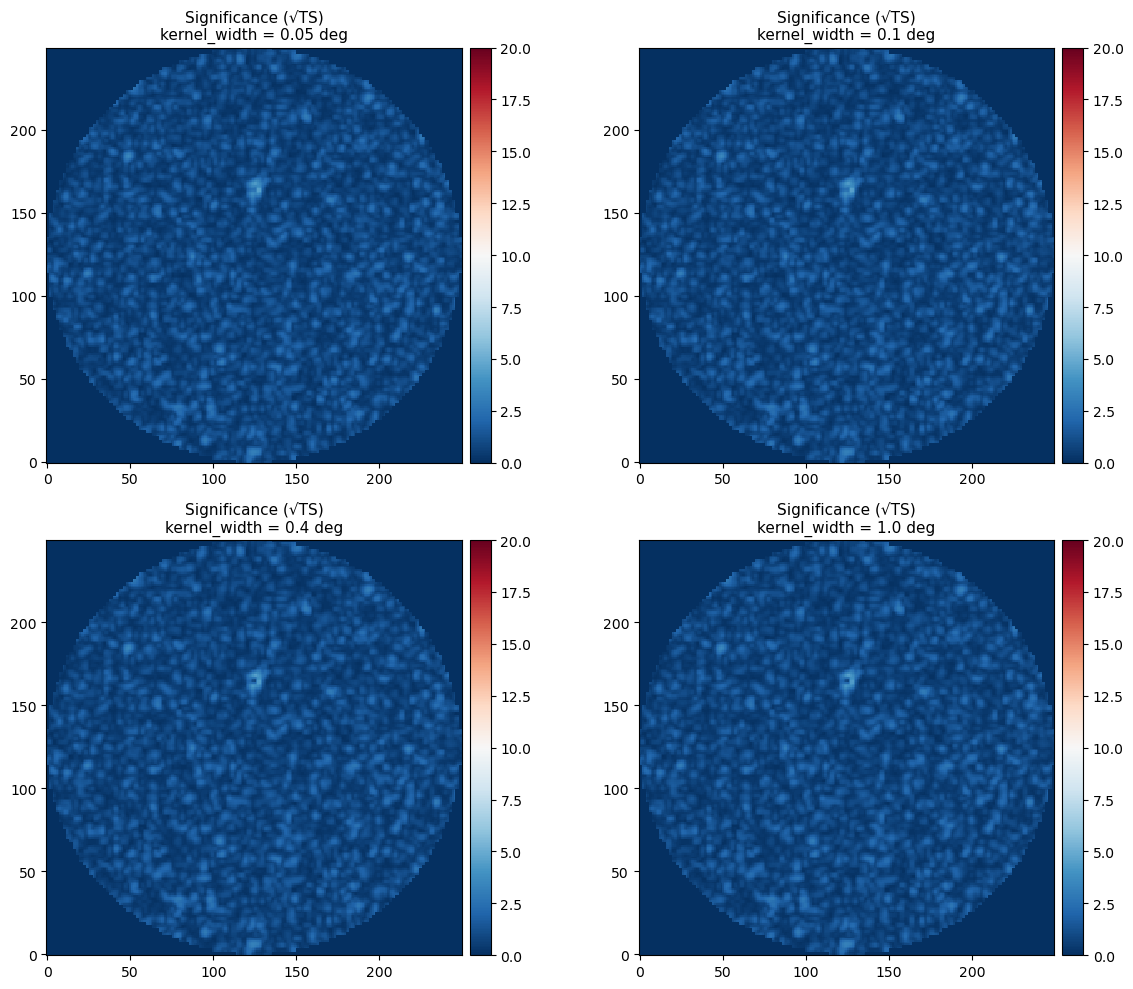

In [ ]:
kernel_widths = ["0.05 deg", "0.1 deg", "0.4 deg", "1.0 deg"]

ts_results = {}

# --- Run TSMapEstimator for each kernel width ---
for kw in kernel_widths:
    ts_estimator = TSMapEstimator(
        model=SkyModel(
            spectral_model=PowerLawSpectralModel(
                index=2.5,
                amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
                reference=1.0 * u.TeV,
            ),
            spatial_model=PointSpatialModel(),
            name="ts-kernel",
        ),
        kernel_width=kw,
        selection_optional=[],
        downsampling_factor=2,
    )
    
    ts_results[kw] = ts_estimator.run(dataset)
    print(f"TS map done for kernel_width = {kw}")

# --- Plot sqrt(TS) (significance) in 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, kw in zip(axes, kernel_widths):
    
    ts_map = ts_results[kw]["ts"].sum_over_axes()
    
    sqrt_ts = ts_map.copy()
    sqrt_ts.data = np.sqrt(np.clip(ts_map.data, 0, None))
    
    sqrt_ts.plot(
        ax=ax, cmap="RdBu_r", vmin=0, vmax=20, add_cbar=True
    )
    
    ax.set_title(f"Significance (√TS)\nkernel_width = {kw}", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#Here we will fit a point souce model at each pixel and return a TS value — proper likelihood fit.

ts_estimator = TSMapEstimator(
    model=SkyModel(
        spectral_model=PowerLawSpectralModel(
            index=2.5,
            amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
            reference=1.0 * u.TeV,
        ),
        spatial_model=PointSpatialModel(),
        name="ts-kernel",
    ),
    kernel_width="1.0 deg",
    selection_optional=[],
    n_sigma=3.0,
    n_sigma_ul=5.0,
    downsampling_factor=2,
)

ts_result = ts_estimator.run(dataset)
print("Available quantities:", ts_result.available_quantities)

Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.


Available quantities: ['ts', 'norm', 'niter', 'norm_err', 'npred', 'npred_excess', 'stat', 'stat_null', 'success']


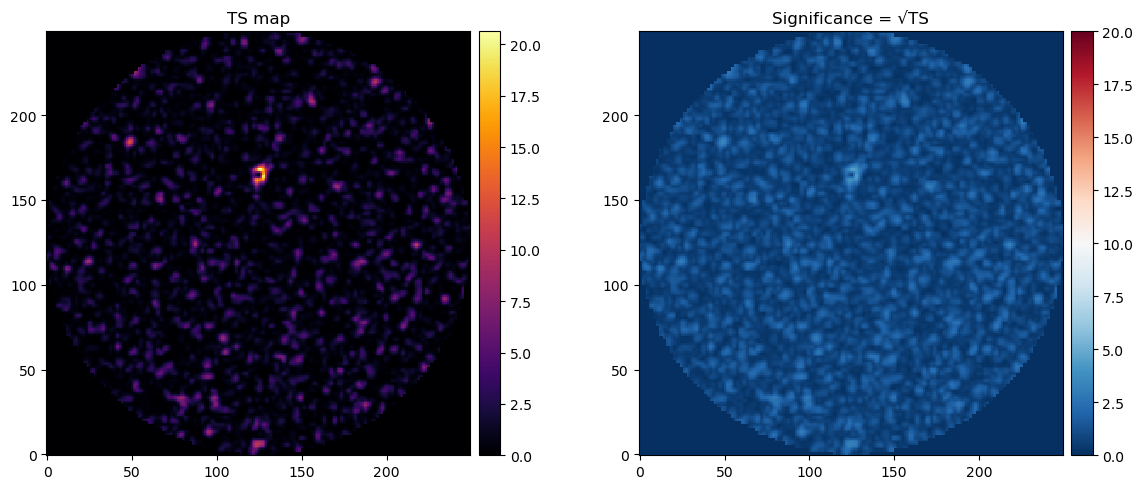

In [ ]:
#Plotting the TS map and the significance map (sqrt(TS)) side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TS map
ts_result["ts"].sum_over_axes().plot(
    ax=axes[0], cmap="inferno", add_cbar=True
)
axes[0].set_title("TS map", fontsize=12)

# sqrt(TS) = significance
import numpy as np
ts_map = ts_result["ts"].sum_over_axes()
sqrt_ts = ts_map.copy()
sqrt_ts.data = np.sqrt(np.clip(ts_map.data, 0, None))
sqrt_ts.plot(
    ax=axes[1], cmap="RdBu_r", vmin=0, vmax=20, add_cbar=True
)
axes[1].set_title("Significance = √TS", fontsize=12)

plt.tight_layout()
#plt.savefig("ts_maps.png", dpi=150, bbox_inches="tight")
plt.show()

#### Comparison Plot for ExcessMap and TSMap

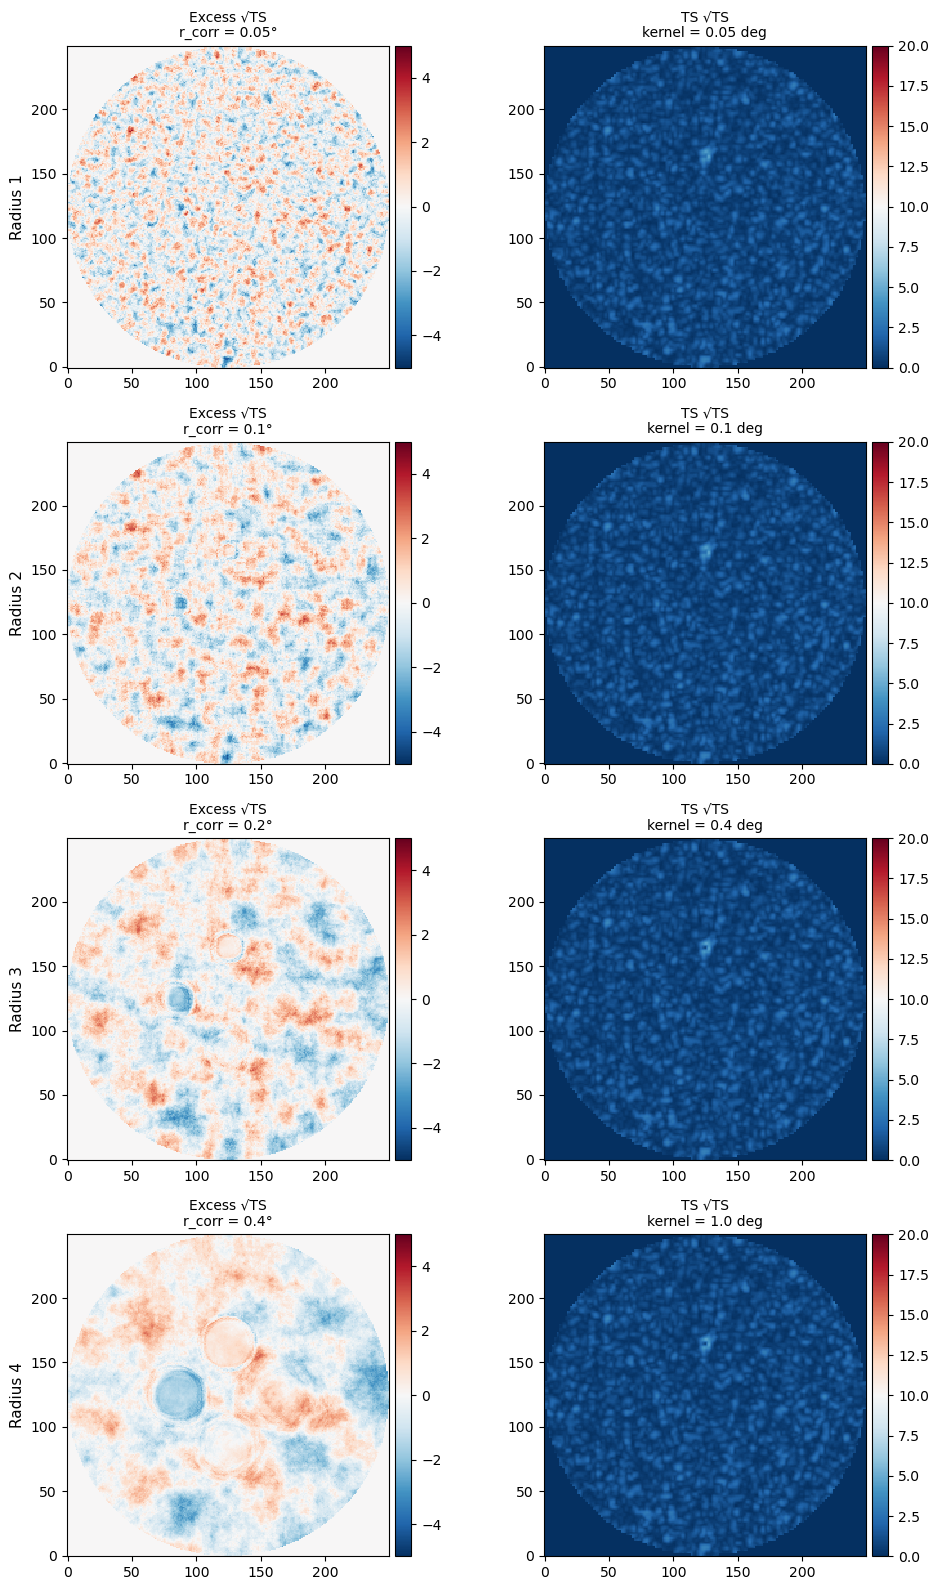

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for i, (r, kw) in enumerate(zip(correlation_radii, kernel_widths)):
    
    # --- ExcessMap (left column) ---
    excess_map = excess_results[r]["sqrt_ts"]
    excess_map.sum_over_axes().plot(
        ax=axes[i, 0], cmap="RdBu_r", vmin=-5, vmax=5, add_cbar=True
    )
    axes[i, 0].set_title(f"Excess √TS\nr_corr = {r}°", fontsize=10)
    
    # --- TSMap (right column) ---
    ts_map = ts_results[kw]["ts"].sum_over_axes()
    
    sqrt_ts = ts_map.copy()
    sqrt_ts.data = np.sqrt(np.clip(ts_map.data, 0, None))
    
    sqrt_ts.plot(
        ax=axes[i, 1], cmap="RdBu_r", vmin=0, vmax=20, add_cbar=True
    )
    axes[i, 1].set_title(f"TS √TS\nkernel = {kw}", fontsize=10)

# Labels
axes[0, 0].set_ylabel("Radius 1", fontsize=11)
axes[1, 0].set_ylabel("Radius 2", fontsize=11)
axes[2, 0].set_ylabel("Radius 3", fontsize=11)
axes[3, 0].set_ylabel("Radius 4", fontsize=11)

plt.tight_layout()
plt.show()

#### ExcessMap
The ExcessMap represents the difference bertween the observed counts and the expected background in each pixel, that is the excess.
$$ Excess = N_{on}-N_{bkg} $$
They allow us to infer how many counts more than the background can we see. The positive access represents a possible source and the negative excess implies a fluctuation.
However, these maps are dominated by flutuations and does not provide a reliable evidence for a source detetcion. We can also note that as the radius of the kernel increases the structures become more smoother and we can observe large blobs which implies that large kernels introduce artificial structures due to over-smoothing.


#### TSMap
A TS map is based on Test Statistics likelihood, where the map represnts the statistical significance of a source being at each pixel. 
The Test Statistic (TS) is defined as:
$$
TS = 2 \left[ \log \mathcal{L}(\text{source}) - \log \mathcal{L}(\text{no source}) \right]
$$
This ensures that the background is mostly flat and the noise is suppressed compared to ExcessMap. It also accounts for Poisson statistics and background contributions, making it a more robust indicator of source detection.

We can also note that the noise becomes suppressed for the higher values of radii but over-smoothing can start at large kernel.


#### From our 4 TSMap and ExcessMap plots we have
- For $r = 0.05°$, only the point source and the $\sigma = 0.05°$ Gaussian are detected above $5\sigma$. 
The broader sources fall below the threshold as the small aperture is not large enough to capture 
sufficient flux from the extended emission.

- For $r = 0.10°$, the $\sigma = 0.10°$ source also becomes statistically significant.

- For $r = 0.20°$ and larger, the $\sigma = 0.20°$ Gaussian is recovered, however the point source 
significance drops as the larger aperture now dilutes the PSF-limited flux with the background.

- The TSMap consistently gives cleaner detections compared to the ExcessMap at all radii, as it 
accounts for the Poisson statistics explicitly rather than relying on Gaussian approximations.


#### Conclusion
Thus, while the excess map shows the amplitude of the signal, the TS map provides a statistically robust measure of its significance.
Therefore for visualization we can use the ExcessMap but for detetcion of a source TSMap is a more reliable tool.